### Compute the volume of a N-dimensional sphere as a function of N using MC techniques

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

Square

In [155]:
R = 2.0
N = int(1e4)

In [172]:
x = np.random.uniform(-R, R, (N, 2))

In [173]:
from scipy.special import gamma

In [180]:
def inside_outside(x, R):
    """Check if points (x, y) are inside a circle of radius R."""
    dist = np.sqrt(np.sum(x**2, axis=1))
    a = dist <= R
    return x[dist <= R], x[dist > R]

def volume(x, R):
    """Calculate the volume of a sphere in N dimensions."""
    return (np.pi ** (x.shape[1] / 2)) / gamma(x.shape[1] / 2 + 1) * R**x.shape[1]

def volume_MC(x, R):
    x_in = inside_outside(x, R)[0]
    try:
        V = (2 * R)**x_in.shape[1] * (len(x_in) / len(x)), x_in
    except:
        V = 0, x_in
    return V

In [181]:
vol, x_in = volume_MC(x, R)

Volume :  2.5446900494077327
Volume (MC) :  0.7848


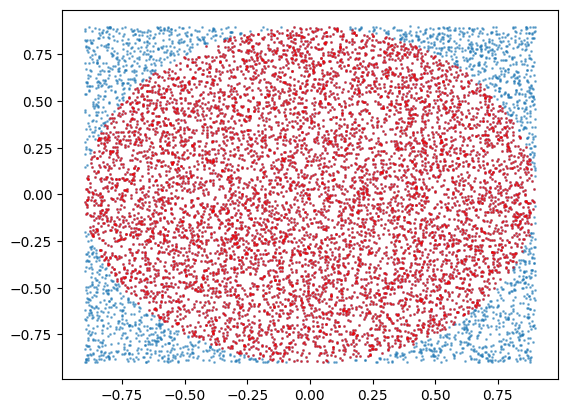

In [176]:
plt.scatter(x.T[0], x.T[1], s=1, alpha=0.5)
plt.scatter(x_in.T[0], x_in.T[1], s=1, color='red', alpha=0.5)

print('Volume : ', volume(x_in, R))
print('Volume (MC) : ',  vol)

M-Dimensional case

In [185]:
R = 2

In [186]:
vols_MC, vols = [], []
Ms = np.linspace(2, 20, 9, dtype=int)
for M in Ms:
    x = np.random.uniform(-1, 1, (N, M))
    vol, xs = volume_MC(x, R)
    vols.append(volume(xs, R))
    vols_MC.append(vol)

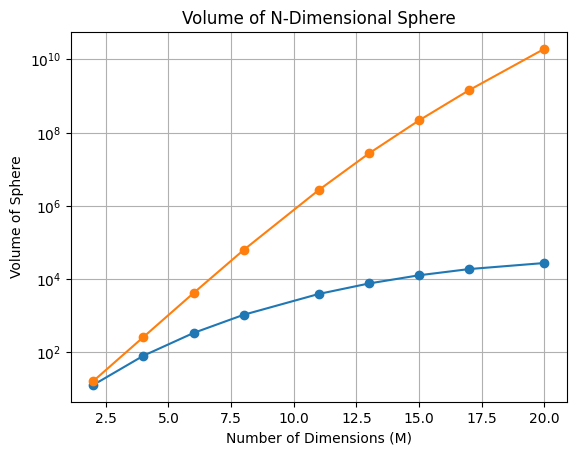

In [187]:
plt.plot(Ms, vols, marker='o')
plt.plot(Ms, vols_MC, marker='o')
plt.yscale('log')
plt.xlabel('Number of Dimensions (M)')
plt.ylabel('Volume of Sphere')
plt.title('Volume of N-Dimensional Sphere')
plt.grid()